# Лабораторная работа: Анализ и предварительная обработка временного ряда PM2.5

## 0. Установка зависимостей и импорт библиотек

In [1]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
from scipy.signal import savgol_filter
from pyts.decomposition import SingularSpectrumAnalysis

## 1. Загрузка данных, формирование временного индекса и выбор выборки

In [3]:
df = pd.read_csv('/content/BeijingPM20100101_20151231.csv')

In [4]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

In [5]:
df.sort_values(by='datetime')

,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec,datetime
0,1,2010,1,1,0,4,NaN,NaN,NaN,NaN,-21.0,43.0,1021.0,-11.0,NW,1.79,0.0,0.0,2010-01-01 00:00:00
1,2,2010,1,1,1,4,NaN,NaN,NaN,NaN,-21.0,47.0,1020.0,-12.0,NW,4.92,0.0,0.0,2010-01-01 01:00:00
2,3,2010,1,1,2,4,NaN,NaN,NaN,NaN,-21.0,43.0,1019.0,-11.0,NW,6.71,0.0,0.0,2010-01-01 02:00:00
3,4,2010,1,1,3,4,NaN,NaN,NaN,NaN,-21.0,55.0,1019.0,-14.0,NW,9.84,0.0,0.0,2010-01-01 03:00:00
4,5,2010,1,1,4,4,NaN,NaN,NaN,NaN,-20.0,51.0,1018.0,-12.0,NW,12.97,0.0,0.0,2010-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52579,52580,2015,12,31,19,4,140.0,157.0,122.0,133.0,-8.0,68.0,1031.0,-3.0,SE,7.14,0.0,0.0,2015-12-31 19:00:00
52580,52581,2015,12,31,20,4,157.0,199.0,149.0,169.0,-8.0,63.0,1030.0,-2.0,SE,8.03,0.0,0.0,2015-12-31 20:00:00
52581,52582,2015,12,31,21,4,171.0,231.0,196.0,203.0,-10.0,73.0,1030.0,-6.0,NE,0.89,0.0,0.0,2015-12-31 21:00:00
52582,52583,2015,12,31,22,4,204.0,242.0,221.0,212.0,-10.0,73.0,1030.0,-6.0,NE,1.78,0.0,0.0,2015-12-31 22:00:00


In [6]:
deltas = df['datetime'].diff()
print(deltas.value_counts())
#шкала регулярна, цикл - каждый час.

datetime
0 days 01:00:00    52583
Name: count, dtype: int64


In [7]:
final_df = df.tail(1000)

In [8]:
final_df = final_df.set_index('datetime', drop=False)

## 2. Предварительная обработка данных и визуализация целевого ряда

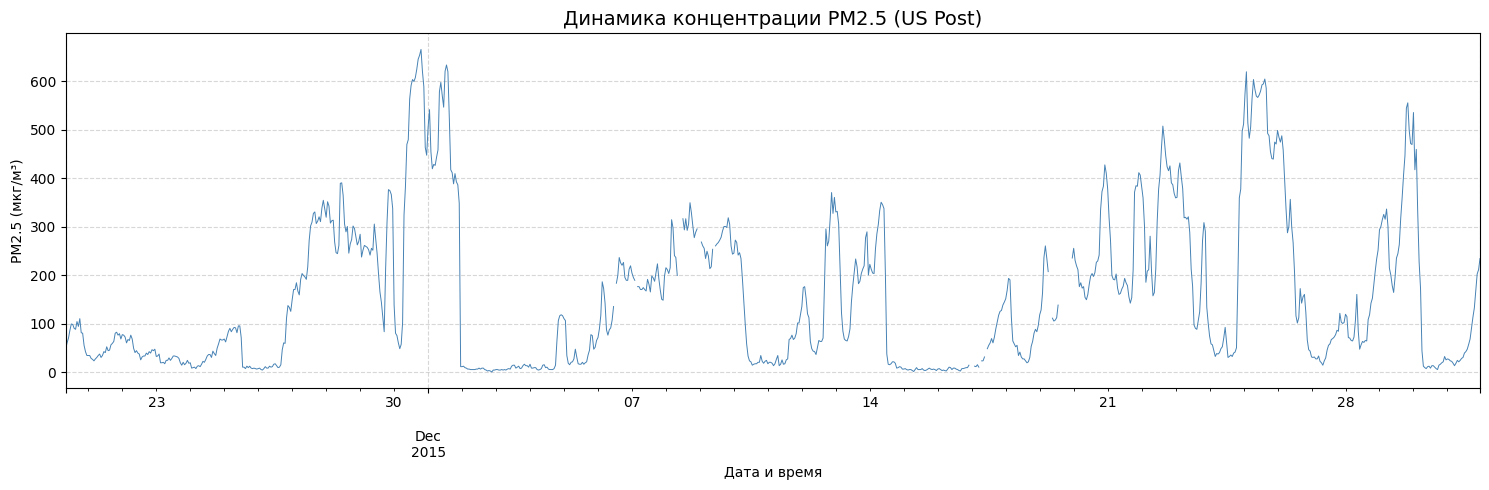

In [9]:
plt.figure(figsize=(15, 5))
final_df['PM_US Post'].plot(linewidth=0.7, color='steelblue')
plt.title('Динамика концентрации PM2.5 (US Post)', fontsize=14)
plt.xlabel('Дата и время')
plt.ylabel('PM2.5 (мкг/м³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
final_df.drop(['PM_Dongsi', 'PM_Dongsihuan', 'PM_Nongzhanguan'], axis=1, inplace=True)

In [11]:
final_df.drop(['DEWP', 'HUMI', 'PRES', 'TEMP','cbwd','Iws','precipitation'], axis=1, inplace=True)

In [12]:
final_df.drop('Iprec', axis=1, inplace=True)

In [13]:
final_df['PM_US Post'] = final_df['PM_US Post'].interpolate(method='time', limit=7)
#интерполировали пропущенные значение не длинее 7 часов подряд, т.к. показания датчиков не должны сильно отличатся в течении короткого времени(1-3 часов)

In [14]:
print(final_df.isna().sum())

No            0
year          0
month         0
day           0
hour          0
season        0
PM_US Post    0
datetime      0
dtype: int64


## 3. Проверка стационарности исходного ряда

In [15]:
series = final_df['PM_US Post']

### 3.1. Расширенный критерий Дики – Фуллера (ADF)

In [16]:
alpha = 0.05

#расширенный критерий Дики - Фуллера
adf = adfuller(series, autolag='AIC')
adf_stat = adf[0]
adf_pvalue = adf[1]
adf_crit_value = adf[4]

/tmp/ipykernel_505/1528486703.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(series, autolag='AIC')


In [17]:
print(f'АДФ статистика : {adf_stat}')
print(f'АДФ pvalue : {adf_pvalue}')
print(f'АДФ критические значения: {adf_crit_value}')

АДФ статистика : -4.452996962594329
АДФ pvalue : 0.00023888815597612693
АДФ критические значения: {'1%': np.float64(-3.4369525024039884), '5%': np.float64(-2.8644550095200705), '10%': np.float64(-2.568322093455802)}


In [18]:
if adf_pvalue < alpha:
  print('HO отвергается, ряд стационарен')
else:
  print('H0 не отвергается, ряд не стационарен')

HO отвергается, ряд стационарен


### 3.2. Критерий Квятковского – Филлипса – Шмидта – Шина (KPSS)

In [19]:
kps = kpss(series, regression='c', nlags='auto')
kps_stat = kps[0]
kps_pvalue = kps[1]
kps_crit_value = kps[3]

/tmp/ipykernel_505/373558406.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kps = kpss(series, regression='c', nlags='auto')
/tmp/ipykernel_505/373558406.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kps = kpss(series, regression='c', nlags='auto')


In [20]:
print(f'КФШШ статистика : {kps_stat}')
print(f'КФШШ pvalue : {kps_pvalue}')
print(f'КФШШ критические значения: {kps_crit_value}')

КФШШ статистика : 0.25944951890122925
КФШШ pvalue : 0.1
КФШШ критические значения: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [21]:
if kps_pvalue < alpha:
    print("H0 отвергается. Ряд НЕСТАЦИОНАРЕН.")
else:
    print("H0 не отвергается. Ряд СТАЦИОНАРЕН.")

H0 не отвергается. Ряд СТАЦИОНАРЕН.


## 4. Обнаружение аномальных значений (выбросов)

### 4.1. Метод межквантильного размаха (IQR)

In [22]:
#выбросы межквантильным размахом:
q1 = final_df['PM_US Post'].quantile(0.25)
q3 = final_df['PM_US Post'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
outliers_mask = (final_df['PM_US Post'] < lower_bound) | (final_df['PM_US Post'] > upper_bound)
outliers = final_df[outliers_mask]
len(outliers)

19

### 4.2. Метод медианного абсолютного отклонения (MAD)

In [23]:
#выбросы медианным абсолютным отклонением
median = final_df['PM_US Post'].median()
d_med = (final_df['PM_US Post'] - median).abs().median()
final_df['zi'] = 0.6745 * (final_df['PM_US Post'] - median) / d_med
outliers_mask1 = final_df['zi'].abs() > 3.5
outliers1 = final_df[outliers_mask1]
len(outliers1)

30

### 4.3. Метод скользящего окна (фильтр Хампеля)

In [24]:
def hampel_filter(series, window_size=25, n_sigmas=3):
    k = 1.4826
    rolling_median = series.rolling(window=window_size, center=True, min_periods=1).median()
    rolling_diff = (series - rolling_median).abs()
    rolling_mad = rolling_diff.rolling(window=window_size, center=True, min_periods=1).median()
    threshold = n_sigmas * k * rolling_mad
    outliers_mask3 = rolling_diff > threshold
    return outliers_mask3, rolling_median

In [25]:
col = 'PM_US Post'
outliers_mask3, local_medians = hampel_filter(final_df[col], window_size=25, n_sigmas=3)
outliers = final_df[outliers_mask3]
print(f"Найдено выбросов фильтром Хампеля: {len(outliers)}")

Найдено выбросов фильтром Хампеля: 50


## 5. Графическое сопоставление обнаруженных выбросов

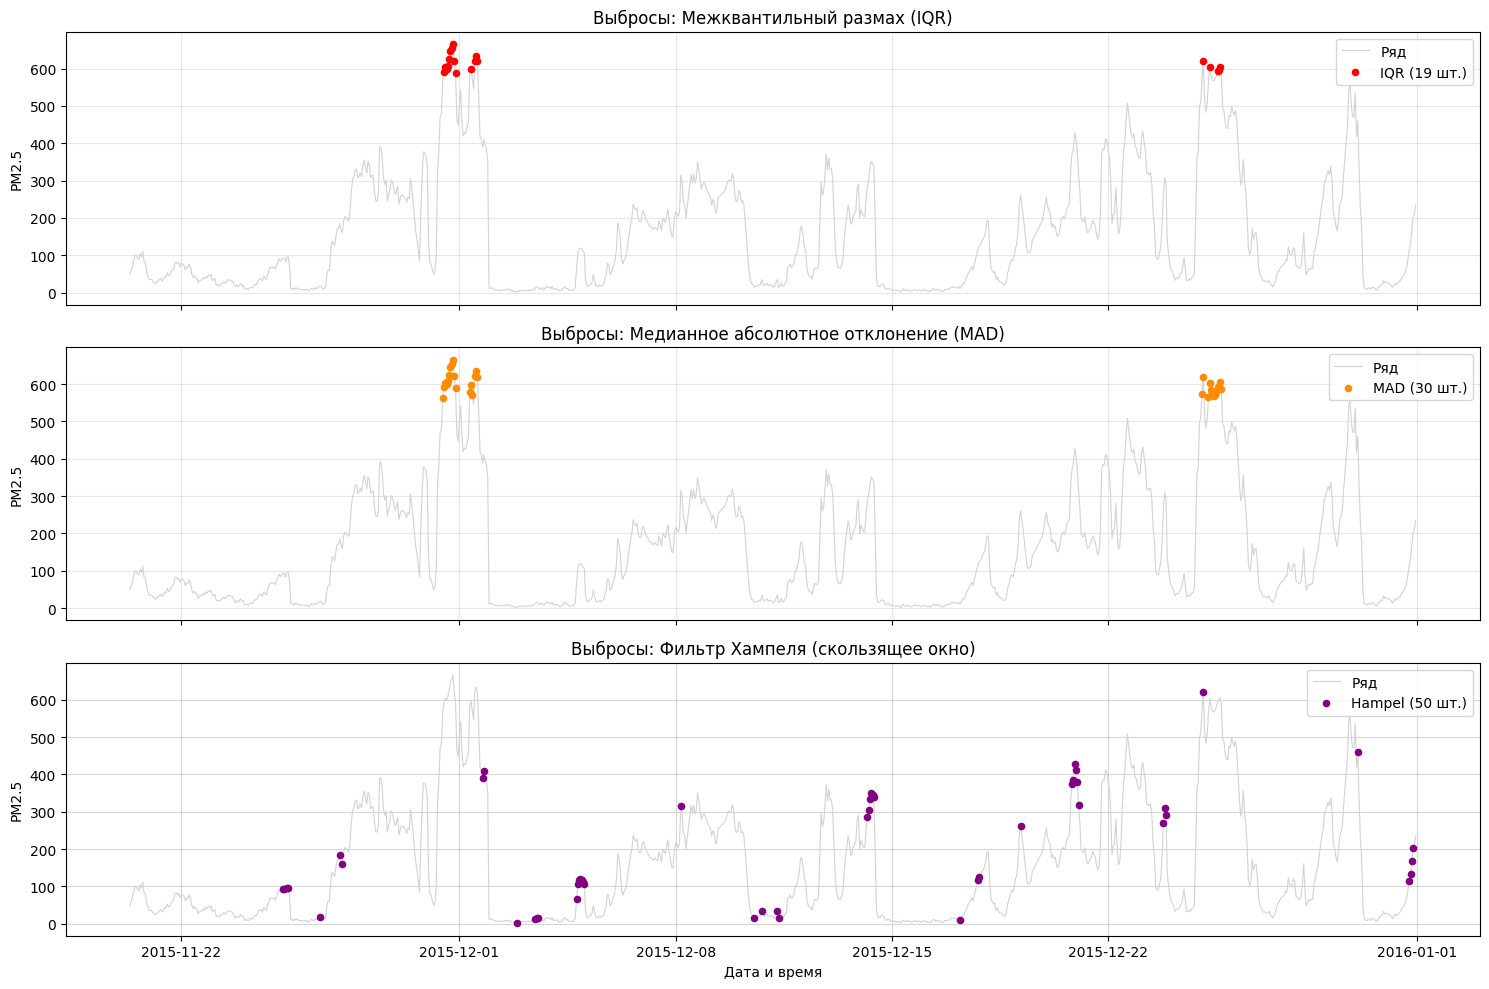

In [26]:
col = 'PM_US Post'

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# 1. Межквантильный размах (IQR)
axes[0].plot(final_df.index, final_df[col], color='lightgray', linewidth=0.8, label='Ряд')
axes[0].scatter(final_df.index[outliers_mask], final_df.loc[outliers_mask, col],
                color='red', s=20, label=f'IQR ({outliers_mask.sum()} шт.)', zorder=3)
axes[0].set_title('Выбросы: Межквантильный размах (IQR)')
axes[0].set_ylabel('PM2.5')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Медианное абсолютное отклонение (MAD)
axes[1].plot(final_df.index, final_df[col], color='lightgray', linewidth=0.8, label='Ряд')
axes[1].scatter(final_df.index[outliers_mask1], final_df.loc[outliers_mask1, col],
                color='darkorange', s=20, label=f'MAD ({outliers_mask1.sum()} шт.)', zorder=3)
axes[1].set_title('Выбросы: Медианное абсолютное отклонение (MAD)')
axes[1].set_ylabel('PM2.5')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# 3. Фильтр Хампеля
axes[2].plot(final_df.index, final_df[col], color='lightgray', linewidth=0.8, label='Ряд')
axes[2].scatter(final_df.index[outliers_mask3], final_df.loc[outliers_mask3, col],
                color='purple', s=20, label=f'Hampel ({outliers_mask3.sum()} шт.)', zorder=3)
axes[2].set_title('Выбросы: Фильтр Хампеля (скользящее окно)')
axes[2].set_ylabel('PM2.5')
axes[2].set_xlabel('Дата и время')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [28]:
col = 'PM_US Post'

# 1. Создаем копию ряда
final_df['PM_cleaned'] = final_df[col].copy()

# 2. Формируем маску истинных технических сбоев:
# берем сбои по Хампелю, но исключаем реальный сильный смог (> 500-550)
real_smog_threshold = 550
sensor_glitches = outliers_mask3 & (final_df[col] < real_smog_threshold)

# 3. Заменяем сбои на NaN и применяем линейную интерполяцию по времени
final_df.loc[sensor_glitches, 'PM_cleaned'] = np.nan
final_df['PM_cleaned'] = final_df['PM_cleaned'].interpolate(method='time')

print(f"Всего выявлено импульсов Хампелем: {outliers_mask3.sum()}")
print(f"Скорректировано аппаратных сбоев: {sensor_glitches.sum()}")
print(f"Сохранено реальных пиков смога: {(outliers_mask3 & ~sensor_glitches).sum()}")

Всего выявлено импульсов Хампелем: 50
Скорректировано аппаратных сбоев: 49
Сохранено реальных пиков смога: 1


In [29]:
outliers_mask_after, local_medians_after = hampel_filter(
    final_df['PM_cleaned'],
    window_size=25,
    n_sigmas=3
)

# 2. Подсчет оставшихся аномалий
before_count = outliers_mask3.sum()
after_count = outliers_mask_after.sum()

print(f"Выбросов до очистки:    {before_count}")
print(f"Выбросов после очистки: {after_count}")

Выбросов до очистки:    50
Выбросов после очистки: 18


Видно, что методы межквартильного рахмаха и МАЗ отметили выбросами максимальные значения, но проблема в том, что такие значения частиц вполне возможны. Фильтр Хампеля же выбрал отдельные значения в 24-часовом окне, из-за чего такие выбросы можно считать реальными выбросами.

# 6. Методы сглаживания

In [30]:
series = final_df['PM_cleaned'].values
time_index = final_df.index
n_points = len(series)
#Скользящее среднее
final_df['mov_mean'] = (
    final_df['PM_cleaned'].rolling(window=25, center=True, min_periods=1).mean()
)

#Скользящая медиана
final_df['mov_med'] = (
    final_df['PM_cleaned'].rolling(window=25, center=True, min_periods=1).median()
)

#фильтр Савицкого-Голея
final_df['sav_gol'] = savgol_filter(series, window_length=25, polyorder=2)

#Преобразования Фурье
fft_coef = np.fft.rfft(series)
n_harmonics = 35
fft_filtered = np.zeros_like(fft_coef)
fft_filtered[:n_harmonics] = fft_coef[:n_harmonics]
final_df['fft'] = np.fft.irfft(fft_filtered, n=n_points)

#SSA
X = series.reshape(1, -1)
ssa = SingularSpectrumAnalysis(window_size=72, groups=[[0, 1, 2]])
X_ssa = ssa.fit_transform(X)
final_df['ssa'] = X_ssa[0]

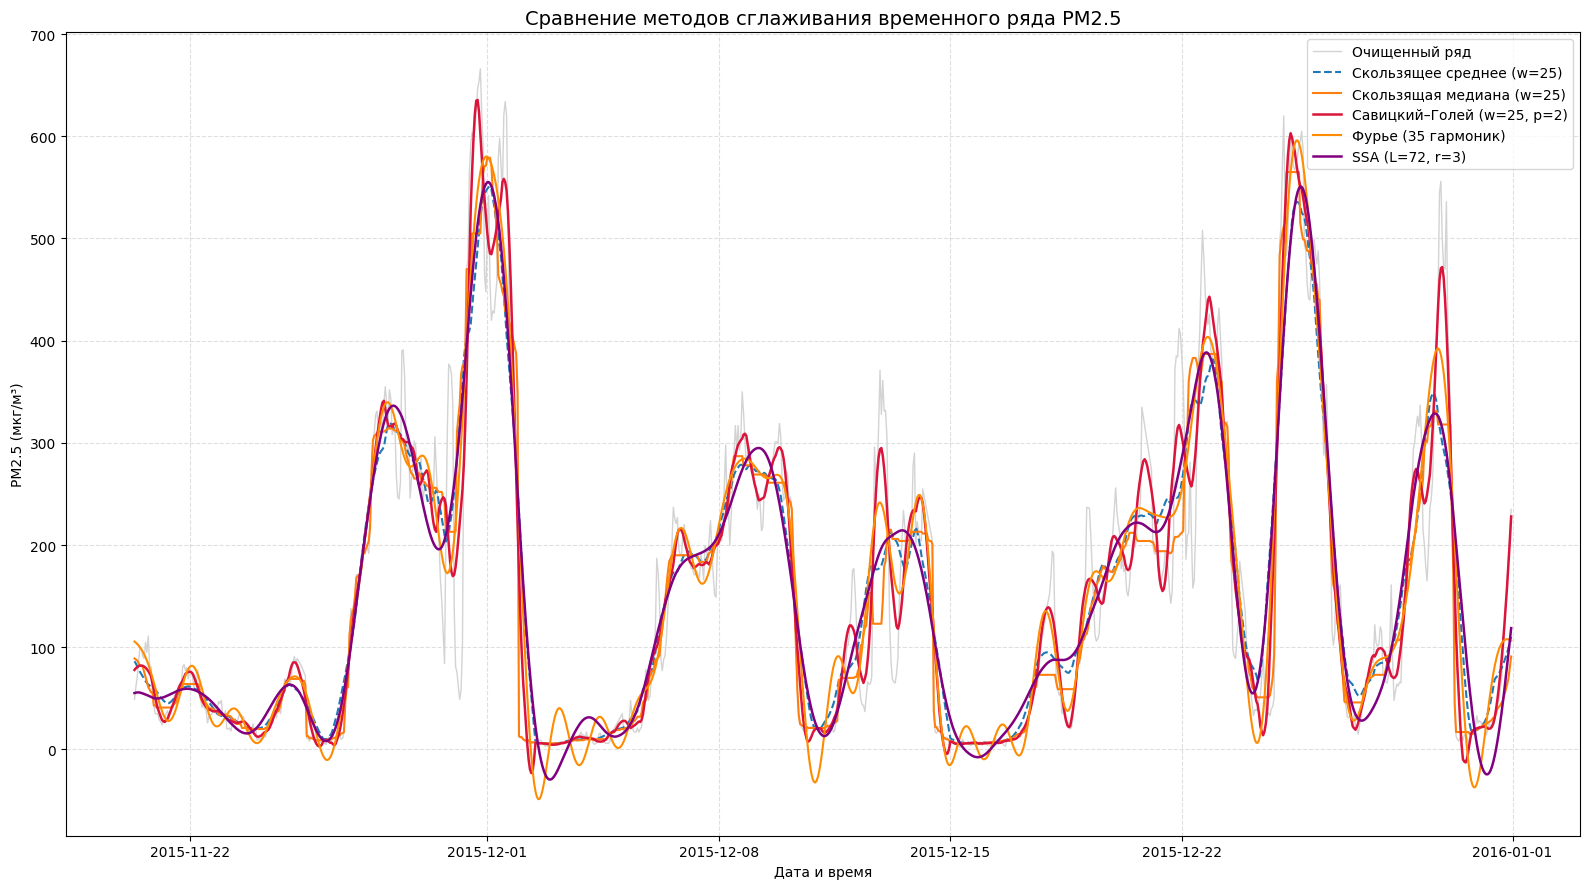

In [31]:
plt.figure(figsize=(16, 9))


plt.plot(final_df.index, final_df['PM_cleaned'], color='lightgray', linewidth=1, label='Очищенный ряд')

plt.plot(final_df.index, final_df['mov_mean'], label='Скользящее среднее (w=25)', linewidth=1.5, linestyle='--')
plt.plot(final_df.index, final_df['mov_med'], label='Скользящая медиана (w=25)', linewidth=1.5)
plt.plot(final_df.index, final_df['sav_gol'], label='Савицкий–Голей (w=25, p=2)', linewidth=1.8, color='crimson')
plt.plot(final_df.index, final_df['fft'], label='Фурье (35 гармоник)', linewidth=1.5, color='darkorange')
plt.plot(final_df.index, final_df['ssa'], label='SSA (L=72, r=3)', linewidth=1.8, color='purple')

plt.title('Сравнение методов сглаживания временного ряда PM2.5', fontsize=14)
plt.xlabel('Дата и время')
plt.ylabel('PM2.5 (мкг/м³)')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 7. Проверка стационарности

In [32]:
#На сглаженных данных
series_savgol = final_df['sav_gol']
adf_savgol = adfuller(series_savgol, autolag='AIC')
kpss_savgol = kpss(series_savgol, regression='c', nlags='auto')
print(f"Савицкий-Голей — ADF p-value:  {adf_savgol[1]:.4e}")
print(f"Савицкий-Голей — KPSS p-value: {kpss_savgol[1]:.4e}")

Савицкий-Голей — ADF p-value:  2.4586e-04
Савицкий-Голей — KPSS p-value: 1.0000e-01


/tmp/ipykernel_505/4158613771.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_savgol = adfuller(series_savgol, autolag='AIC')
/tmp/ipykernel_505/4158613771.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_savgol = kpss(series_savgol, regression='c', nlags='auto')
/tmp/ipykernel_505/4158613771.py:4: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to 

In [33]:
if adf_savgol[1] < alpha:
    print(f"   Вывод ADF: p-value < {alpha} -> H0 отвергается. Ряд СТАЦИОНАРЕН.")
else:
    print(f"   Вывод ADF: p-value >= {alpha} -> H0 принимается. Ряд НЕСТАЦИОНАРЕН.")

if kpss_savgol[1] < alpha:
    print(f"   Вывод KPSS: p-value < {alpha} -> H0 отвергается. Ряд НЕСТАЦИОНАРЕН.")
else:
    print(f"   Вывод KPSS: p-value >= {alpha} -> H0 принимается. Ряд СТАЦИОНАРЕН.")

   Вывод ADF: p-value < 0.05 -> H0 отвергается. Ряд СТАЦИОНАРЕН.
   Вывод KPSS: p-value >= 0.05 -> H0 принимается. Ряд СТАЦИОНАРЕН.


In [35]:
#На очищенных данных:
series_clean = final_df['PM_cleaned']
adf_clean = adfuller(series_clean, autolag='AIC')
kpss_clean = kpss(series_clean, regression='c', nlags='auto')
print(f"Очищенные данные — ADF p-value:  {adf_clean[1]:.4e}")
print(f"Очищенные данные — KPSS p-value: {kpss_clean[1]:.4e}")

Очищенные данные — ADF p-value:  9.9840e-05
Очищенные данные — KPSS p-value: 1.0000e-01


/tmp/ipykernel_505/3635419529.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_clean = adfuller(series_clean, autolag='AIC')
/tmp/ipykernel_505/3635419529.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_clean = kpss(series_clean, regression='c', nlags='auto')
/tmp/ipykernel_505/3635419529.py:4: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to alwa

In [36]:
if adf_clean[1] < alpha:
    print(f"   Вывод ADF: p-value < {alpha} -> H0 отвергается. Ряд СТАЦИОНАРЕН.")
else:
    print(f"   Вывод ADF: p-value >= {alpha} -> H0 принимается. Ряд НЕСТАЦИОНАРЕН.")

if kpss_clean[1] < alpha:
    print(f"   Вывод KPSS: p-value < {alpha} -> H0 отвергается. Ряд НЕСТАЦИОНАРЕН.")
else:
    print(f"   Вывод KPSS: p-value >= {alpha} -> H0 принимается. Ряд СТАЦИОНАРЕН.")

   Вывод ADF: p-value < 0.05 -> H0 отвергается. Ряд СТАЦИОНАРЕН.
   Вывод KPSS: p-value >= 0.05 -> H0 принимается. Ряд СТАЦИОНАРЕН.
